## Training Ridge Regression

<table>
        <thead>
            <tr>
                <th rowspan="2">Modelo</th>
                <th rowspan="2">Acurácia</th>
                <th colspan="2">Precisão</th>
                <th colspan="2">Recall</th>
                <th colspan="2">F1-Score</th>
            </tr>
            <tr>
                <th>Classe 0</th>
                <th>Classe 1</th>
                <th>Classe 0</th>
                <th>Classe 1</th>
                <th>Classe 0</th>
                <th>Classe 1</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>NB - All</td>
                <td>78%</td>
                <td>0.66</td>
                <td>0.82</td>
                <td>0.60</td>
                <td>0.86</td>
                <td>0.63</td>
                <td>0.84</td>
            </tr>
            <tr>
                <td>NB - Selected</td>
                <td>77%</td>
                <td>0.65</td>
                <td>0.82</td>
                <td>0.61</td>
                <td>0.85</td>
                <td>0.63</td>
                <td>0.84</td>
            </tr>
</table>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### Recovering the data

In [2]:
X_train = pd.read_csv("../datasets/opckd_datasets/X_train.csv")
X_test  = pd.read_csv("../datasets/opckd_datasets/X_test.csv")
y_train = pd.read_csv("../datasets/opckd_datasets/y_train.csv").values.ravel()
y_test  = pd.read_csv("../datasets/opckd_datasets/y_test.csv").values.ravel()

In [3]:
print("Shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Shapes:
X_train: (7242, 27)
X_test: (1323, 27)
y_train: (7242,)
y_test: (1323,)


#### Training the RR with all variables

In [4]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import GridSearchCV

In [5]:
rr = RidgeClassifier(random_state=42)

In [6]:
param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
    'class_weight': [None, 'balanced']
}

In [7]:
# applying hyperparameter selection with Grid Search
grid = GridSearchCV(
    estimator=rr,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

In [8]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 140 candidates, totalling 700 fits


GridSearchCV(cv=5, estimator=RidgeClassifier(random_state=42), n_jobs=-1,
             param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
                         'class_weight': [None, 'balanced'],
                         'fit_intercept': [True, False],
                         'solver': ['auto', 'svd', 'cholesky', 'lsqr',
                                    'sparse_cg', 'sag', 'saga']},
             scoring='accuracy', verbose=2)

In [9]:
print("Melhores hiperparâmetros encontrados:")
print(grid.best_params_)
print("\nMelhor score de validação:", grid.best_score_)

Melhores hiperparâmetros encontrados:
{'alpha': 10.0, 'class_weight': None, 'fit_intercept': True, 'solver': 'auto'}

Melhor score de validação: 0.7318452619257327


In [10]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

##### Results of the model with all the features

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns

In [12]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

In [13]:
print("\n==================== MÉTRICAS ====================")
print(f"Acurácia:  {acc:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")


==================== MÉTRICAS ====================
Acurácia:  0.7188
Precisão:  0.7457
Recall:    0.7188
F1-score:  0.7265


In [14]:
print("\n==================== CLASSIFICATION REPORT ====================")
print(classification_report(y_test, y_pred, zero_division=0))


==================== CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

           0       0.54      0.70      0.61       418
           1       0.84      0.73      0.78       905

    accuracy                           0.72      1323
   macro avg       0.69      0.71      0.70      1323
weighted avg       0.75      0.72      0.73      1323



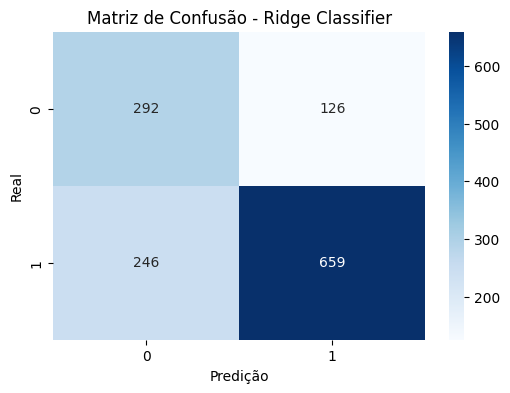

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - Ridge Classifier")
plt.xlabel("Predição")
plt.ylabel("Real")
plt.show()

#### Training the RR with the K selected variables

In [16]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

In [17]:
feature_names = X_train.columns.tolist()
n_features = X_train.shape[1]
k_values = list(range(1, n_features + 1))

In [18]:
pipe = Pipeline([
    ("select", SelectKBest(score_func=f_classif)),
    ("rr", RidgeClassifier(random_state=42))
])

In [19]:
param_grid = {
    "select__k": k_values,
    "rr__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
    "rr__solver": ['auto', 'saga', 'lsqr'],
    "rr__class_weight": [None, 'balanced']
}

In [20]:
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    return_train_score=False,
    n_jobs=-1
)

In [21]:
grid.fit(X_train, y_train)
results = grid.cv_results_

print("\n Melhor combinação encontrada:")
print(grid.best_params_)

best_k = grid.best_params_["select__k"]
print(f"\n Melhor K encontrado: {best_k}")


 Melhor combinação encontrada:
{'rr__alpha': 10.0, 'rr__class_weight': None, 'rr__solver': 'auto', 'select__k': 22}

 Melhor K encontrado: 22


c:\Users\luizf\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [22] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\luizf\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [22]:
best_selector = grid.best_estimator_.named_steps["select"]
mask = best_selector.get_support()
selected_features = X_train.columns[mask].tolist()

print("\n Features selecionadas:")
for f in selected_features:
    print(" -", f)


 Features selecionadas:
 - Cre
 - eGFR
 - Age
 - BMI
 - Albumin
 - Calcium
 - Phosphate
 - ALP
 - HbA1c
 - Glucose
 - WBC
 - HGB
 - Gender
 - Steroid usage
 - OA
 - DM
 - CVA
 - Cataract
 - Fragility fracture hx
 - Hyperthyroidism
 - Hypogonadism
 - Malnutrition


In [23]:
X_train_sel = best_selector.transform(X_train)
X_test_sel  = best_selector.transform(X_test)

In [24]:
best_rr = grid.best_estimator_.named_steps["rr"]
best_rr.fit(X_train_sel, y_train)

RidgeClassifier(alpha=10.0, random_state=42)

In [25]:
y_pred = best_rr.predict(X_test_sel)

##### Results of the model with the selected features

In [26]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

In [27]:
print("\n==================== MÉTRICAS MODELO FINAL ====================")
print(f"Acurácia:   {acc:.4f}")
print(f"Precisão:   {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1-score:   {f1:.4f}")


==================== MÉTRICAS MODELO FINAL ====================
Acurácia:   0.7196
Precisão:   0.7467
Recall:     0.7196
F1-score:   0.7273


In [28]:
print("\n==================== CLASSIFICATION REPORT ====================")
print(classification_report(y_test, y_pred, zero_division=0))


==================== CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

           0       0.54      0.70      0.61       418
           1       0.84      0.73      0.78       905

    accuracy                           0.72      1323
   macro avg       0.69      0.71      0.70      1323
weighted avg       0.75      0.72      0.73      1323



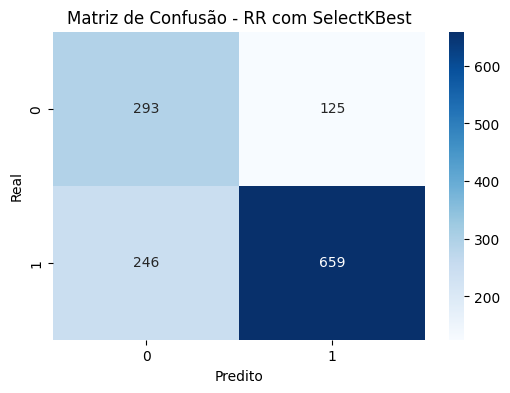

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - RR com SelectKBest")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [30]:
from sklearn.model_selection import learning_curve

In [31]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_rr,
    X=X_train_sel,
    y=y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

In [32]:
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

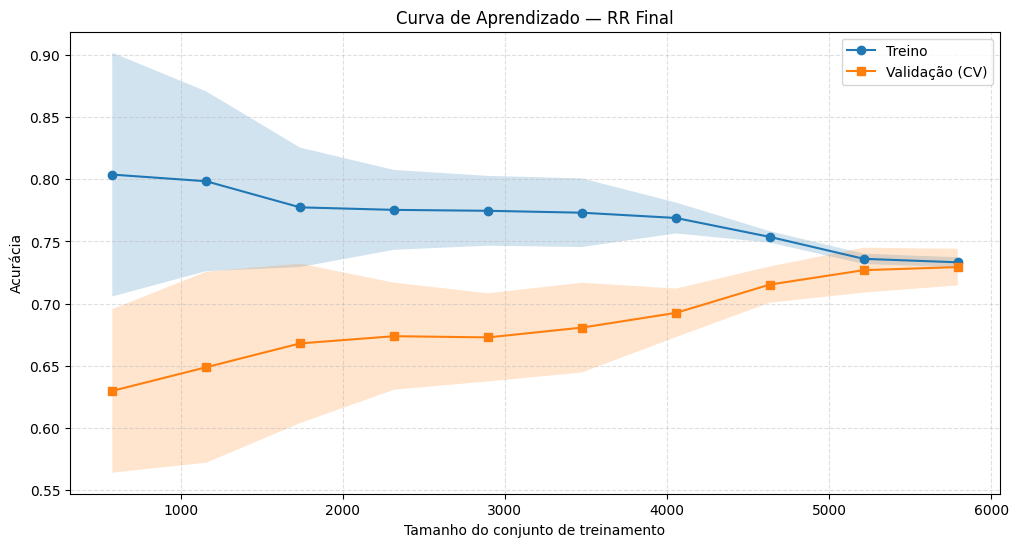

In [33]:
plt.figure(figsize=(12,6))
plt.plot(train_sizes, train_mean, marker="o", label="Treino")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

plt.plot(train_sizes, val_mean, marker="s", label="Validação (CV)")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Curva de Aprendizado — RR Final")
plt.xlabel("Tamanho do conjunto de treinamento")
plt.ylabel("Acurácia")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()